## Requisitos del entorno

Ejecutar este notebook en un entorno con `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `seaborn`, `matplotlib`, `plotly`, `openpyxl`, `joblib` y `gdown` previamente instalados.

> **Secuencia de ejecución CRISP-DM:**
> 1. `01_carga_datos.ipynb — Fase 1: Comprensión del negocio + Carga de datos`
> 2. `02_limpieza_variables.ipynb — Fase 2: Comprensión y preparación de datos`
> 3. `03_universo_analitico.ipynb — Fase 3: Preparación de datos (integración y variables económicas)`
> 4. `04_modelado.ipynb — Fase 4: Modelado (WLS + KMeans)`
> 5. `05_modelo_hibrido.ipynb — Fase 4b: Modelo Híbrido (residuos + clasificador)`
> 6. `06_evaluacion_implementacion.ipynb — Fase 5-6: Evaluación + Implementación`

> ⚠️ **Este notebook requiere haber ejecutado `04_modelado.ipynb` previamente.**

> ➡️ **Siguiente notebook: `06_evaluacion_implementacion.ipynb`**

![Universidad Central](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)

<h2 align="center">Procesamiento y análisis de datos</h2>

<table>
<tr>
<td style="width: 75%; vertical-align: middle;">

## Estimación del gasto personal como variable principal para la evaluación de la capacidad de endeudamiento a partir de la caracterización de los hogares desde la analítica de datos.

**FASE 4b — Modelo Híbrido: Segmentación con Residuos WLS + Clasificador de Producción**

**CRISP-DM Fase 4 (Híbrido):** K-Means con residuos WLS (H1), clasificador supervisado de producción (H2), tabla de ratios híbrida (H3) y exportación de artefactos (H4).

</td>
<td style="width: 25%; text-align: center;">

<img src="https://raw.githubusercontent.com/lpaolav/bases-de-datos/main/gasto_personal.png" width="150">

</td>
</tr>
</table>

---

### Estudiantes:
- Oscar Leonardo Duarte Urrego  
- Paola Andrea Velandia Lozano  

### Director de Tesis:
- Miguel Hernández Bejarano

---


---
## 📦 Carga de datos — NB05
> Ejecuta esta celda primero si no vienes de ejecutar `04_modelado.ipynb` en la misma sesión.

In [1]:

# ============================================================
# CARGA DE DATOS — INICIO NB05
# Requiere haber ejecutado NB04 (04_modelado.ipynb)
# ============================================================
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import os, warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

SEED         = int(os.getenv("TESIS_RANDOM_STATE", "42"))
CLUSTER_SEED = int(os.getenv("TESIS_CLUSTER_RANDOM_STATE", "42"))
N_CLUSTERS   = int(os.getenv("TESIS_N_CLUSTERS", "4"))

_cwd = Path.cwd()
BASE_PATH = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
PERSIST_DIR   = BASE_PATH / "02_intermedios"
OUTPUT_DIR    = BASE_PATH / "produccion"
ARTIFACTS_DIR = OUTPUT_DIR / "modelos"

# Cargar dataset con cluster_final de NB04
print("📦 Cargando datos y artefactos desde NB04...")
df_temp_a = pd.read_parquet(PERSIST_DIR / "nb04_df_modelado.parquet")

# Cargar artefactos del modelo WLS (generados en NB04)
# Busca el pkl en el directorio de trabajo Y en la raíz del proyecto
artifact_v2 = Path.cwd() / 'artefactos_modelo_v2.pkl'
if not artifact_v2.exists():
    artifact_v2 = BASE_PATH / 'notebooks' / 'artefactos_modelo_v2.pkl'
if not artifact_v2.exists():
    artifact_v2 = BASE_PATH / 'artefactos_modelo_v2.pkl'
if artifact_v2.exists():
    artefactos_v2    = joblib.load(artifact_v2)
    model_wls        = artefactos_v2['modelo_regresion']   # clave real en v2
    preprocess_cluster = artefactos_v2.get('preprocess_cluster')
    kmeans_v2        = artefactos_v2.get('modelo_kmeans')
    FEATURES         = artefactos_v2.get('features_regresion', [])
    NUM_VARS         = artefactos_v2.get('num_vars_cluster', [])
    CAT_VARS         = artefactos_v2.get('cat_vars_cluster', [])
    N_CLUSTERS       = artefactos_v2.get('n_clusters', N_CLUSTERS)
    # TARGET se deduce de las features (log_gastos_2025 por convención)
    TARGET           = 'log_gastos_2025'
    print(f"  ✓ artefactos_modelo_v2.pkl cargado — WLS listo")
    print(f"  ✓ Claves disponibles: {sorted(artefactos_v2.keys())}")
else:
    raise FileNotFoundError("No se encontró artefactos_modelo_v2.pkl — ejecuta NB04 primero.")

TARGET_PERIOD = int(os.getenv("TESIS_TARGET_PERIOD", "202512"))

print(f"✅ NB05 listo — df_temp_a: {df_temp_a.shape}")


📦 Cargando datos y artefactos desde NB04...


  ✓ artefactos_modelo_v2.pkl cargado — WLS listo
  ✓ Claves disponibles: ['cat_vars_cluster', 'cluster_map', 'features_regresion', 'modelo_kmeans', 'modelo_regresion', 'n_clusters', 'num_vars_cluster', 'preprocess_cluster', 'ratio_table', 'residuo_global', 'smmlv_2025']
✅ NB05 listo — df_temp_a: (59776, 76)


## Modelo Híbrido — Segmentación con Residuos WLS + Clasificador de Producción

### Principio metodológico

El modelo híbrido opera en **dos etapas separadas**:

**Etapa 1 — Entrenamiento (offline, con datos ENPH):**
1. El modelo WLS estima `log_gasto` y genera `residuo_log_gasto_w = log_gasto_real − log_gasto_estimado`.
2. El K-Means se entrena sobre variables socioeconómicas + `residuo_log_gasto_w`, capturando heterogeneidad comportamental no explicada por el perfil.
3. Un clasificador supervisado ligero (Regresión Logística Multinomial) aprende a predecir el clúster a partir **solo del perfil socioeconómico**, sin el residuo.

**Etapa 2 — Producción (originación crediticia, sin datos de gasto real):**
1. WLS estima el gasto del solicitante → ratio estimado.
2. El clasificador asigna el clúster a partir del perfil socioeconómico.
3. La `RATIO_TABLE` del clúster provee los percentiles de referencia.

> **Ventaja clave**: los clústeres capturan comportamiento real (ahorradores vs. consumidores por encima de su perfil), pero la asignación en producción no requiere el gasto real — solo el perfil verificable en originación.

In [2]:
# ==============================================================================
# BLOQUE H1 — K-MEANS HÍBRIDO CON RESIDUOS WLS
# Entrena el K-Means sobre variables socioeconómicas + residuo_log_gasto_w
# El residuo captura cuánto se desvía el gasto real del esperado por el perfil:
#   residuo > 0 → gasta más de lo que su perfil predice (mayor presión financiera)
#   residuo < 0 → gasta menos de lo esperado (ahorradores o transferencias externas)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Variables para el K-Means híbrido ─────────────────────────────────────────
# Incluye el residuo WLS como variable adicional al espacio de segmentación.
# El residuo está disponible en entrenamiento porque tenemos gasto real (ENPH).
# En producción esta variable NO se usa — el clasificador la reemplaza.
NUM_KM_H = [
    'log_ingresos_2025',
    'log_gasto_pred_w',
    'log_ratio_estimado',
    'Estrato',
    'residuo_log_gasto_w',      # ← DIMENSIÓN HÍBRIDA: comportamiento no explicado
]
CAT_KM_H = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
]
VARS_KM_H = NUM_KM_H + CAT_KM_H

# ── Preparar dataset ───────────────────────────────────────────────────────────
df_km_h = df_temp_a[VARS_KM_H].copy()
df_km_h = df_km_h.dropna()

print(f"Registros para K-Means híbrido: {len(df_km_h):,}")
print(f"Registros excluidos (NaN): {len(df_temp_a) - len(df_km_h):,}")

# ── Diagnóstico del residuo ────────────────────────────────────────────────────
fex_km_h = pd.to_numeric(
    df_temp_a.loc[df_km_h.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
).fillna(1.0)

resid_vals = df_km_h['residuo_log_gasto_w'].values
w_vals     = fex_km_h.values

print("\n── Distribución del residuo WLS (ponderado FEX_C) ───────────────")
print(f"  Media    : {np.average(resid_vals, weights=w_vals):+.4f}  (debe ser ≈ 0)")
print(f"  Mediana  : {np.median(resid_vals):+.4f}")
print(f"  P25      : {np.percentile(resid_vals, 25):+.4f}")
print(f"  P75      : {np.percentile(resid_vals, 75):+.4f}")
print(f"  σ        : {np.std(resid_vals):.4f}")
print(f"  Rango    : [{resid_vals.min():+.3f}, {resid_vals.max():+.3f}]")

# ── Preprocesamiento ───────────────────────────────────────────────────────────
preprocess_km_h = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM_H),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), CAT_KM_H)
])

X_km_h = preprocess_km_h.fit_transform(df_km_h)
fex_km_h_norm = (fex_km_h / fex_km_h.mean()).fillna(1.0).values

print(f"\nMatriz K-Means híbrido: {X_km_h.shape}")

# ── Método del codo — validación con residuo ──────────────────────────────────
print("\n── Método del codo (K-Means híbrido) ────────────────────────────")
inercias_h = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=CLUSTER_SEED, n_init=10)
    km_tmp.fit(X_km_h, sample_weight=fex_km_h_norm)
    inercias_h.append({'k': k, 'inercia': round(km_tmp.inertia_, 0)})

df_codo_h = pd.DataFrame(inercias_h)
df_codo_h['reduccion_marginal'] = df_codo_h['inercia'].diff(-1).abs().shift(1)
print(df_codo_h.to_string(index=False))

# ── K-Means final híbrido ──────────────────────────────────────────────────────
kmeans_hibrido = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=CLUSTER_SEED,
    n_init=30
)
kmeans_hibrido.fit(X_km_h, sample_weight=fex_km_h_norm)

# Asignar etiquetas
df_temp_a['cluster_hibrido_raw'] = np.nan
df_temp_a.loc[df_km_h.index, 'cluster_hibrido_raw'] = (
    kmeans_hibrido.predict(X_km_h)
)

# ── Estadísticas por clúster híbrido ──────────────────────────────────────────
fex_full = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

stats_h = (
    df_temp_a.dropna(subset=['cluster_hibrido_raw'])
    .groupby('cluster_hibrido_raw')
    .agg(
        ingreso_mediano   =('INGRESOS_AL_2025',     'median'),
        gasto_obs_mediano =('GASTOS_AL_2025',        'median'),
        gasto_est_mediano =('gasto_estimado',        'median'),
        residuo_mediano   =('residuo_log_gasto_w',   'median'),
        ratio_obs_mediano =('ratio_gastos_2025',     'median'),
        ratio_est_mediano =('ratio_estimado',        'median'),
        n_muestra         =('log_gastos_2025',       'count'),
    )
)
stats_h['pop_expandida'] = (
    df_temp_a.dropna(subset=['cluster_hibrido_raw'])
    .groupby('cluster_hibrido_raw')
    .apply(lambda g: pd.to_numeric(
        g['FEX_C'].astype(str).str.replace(',', '.', regex=False),
        errors='coerce').sum())
)
stats_h['part_pct'] = (
    stats_h['pop_expandida'] / stats_h['pop_expandida'].sum() * 100
).round(1)

print("\n── Estadísticas por clúster híbrido ─────────────────────────────")
print(stats_h.round(2).to_string())

# Ordenar clusters por residuo mediano ascendente
# (clúster 0 = mayor ahorro relativo, clúster 3 = mayor presión financiera)
orden_h = stats_h['residuo_mediano'].sort_values().index.tolist()
cluster_map_h = {int(raw): int(orden_h.index(raw)) for raw in orden_h}
df_temp_a['cluster_hibrido'] = (
    df_temp_a['cluster_hibrido_raw'].map(cluster_map_h)
)

print("\n── Mapa de reordenamiento (por residuo mediano ascendente) ───────")
print(f"  {cluster_map_h}")
print("\n  Interpretación semántica:")
interpretacion = {
    0: "Gasto bajo relativo — ahorradores o transferencias externas (residuo < 0)",
    1: "Gasto acorde al perfil — comportamiento consistente con ingreso",
    2: "Ingreso medio-alto — gasto moderado, holgura presupuestal",
    3: "Gasto alto relativo — presión financiera por encima del perfil (residuo > 0)",
}
for k, desc in interpretacion.items():
    print(f"  Clúster {k}: {desc}")

print("\n✓ K-Means híbrido entrenado y clúster asignado en df_temp_a['cluster_hibrido']")


Registros para K-Means híbrido: 59,776
Registros excluidos (NaN): 0

── Distribución del residuo WLS (ponderado FEX_C) ───────────────
  Media    : -0.0026  (debe ser ≈ 0)
  Mediana  : +0.0040
  P25      : -0.3924
  P75      : +0.3886
  σ        : 0.6158
  Rango    : [-8.832, +2.703]

Matriz K-Means híbrido: (59776, 27)

── Método del codo (K-Means híbrido) ────────────────────────────


 k  inercia  reduccion_marginal
 2 400621.0                 NaN
 3 354419.0             46202.0
 4 335294.0             19125.0
 5 318568.0             16726.0
 6 306149.0             12419.0
 7 295529.0             10620.0
 8 287076.0              8453.0



── Estadísticas por clúster híbrido ─────────────────────────────
                     ingreso_mediano  gasto_obs_mediano  gasto_est_mediano  residuo_mediano  ratio_obs_mediano  ratio_est_mediano  n_muestra  pop_expandida  part_pct
cluster_hibrido_raw                                                                                                                                                  
0.0                        1524738.0           200411.0          299820.76            -0.39               0.12               0.18      14569     1987392.05      24.4
1.0                        1461711.0           556978.0          352441.97             0.47               0.34               0.22      16083     2107376.38      25.8
2.0                        4944721.0           776064.0          775165.67            -0.01               0.14               0.15      10398     1580690.70      19.4
3.0                        1600295.0           515902.0          561899.30            -0.09            

### H1b — Reordenamiento y etiquetas finales (valores fijos de resultados reales)

Con `cluster_map_h = {2:0, 0:1, 3:2, 1:3}` los cuatro segmentos ordenados por riesgo crediticio son:

| Clúster ord. | Ingreso P50 | Residuo P50 | Ratio obs P50 | Perfil crediticio |
|---|---|---|---|---|
| **0** | $4.94M | −0.01 | 14% | Alto ingreso, gasto controlado — riesgo mínimo |
| **1** | $1.52M | −0.39 | 12% | Bajo ingreso, ahorradores — holgura oculta |
| **2** | $1.60M | −0.09 | 30% | Bajo ingreso, comportamiento típico — presión moderada |
| **3** | $1.46M | +0.47 | 34% | Bajo ingreso, **sobregasto** — máxima presión financiera |

> Separación P50 residuo: **0.859** — excelente discriminación comportamental.

In [3]:
# ==============================================================================
# BLOQUE H1b — REORDENAMIENTO Y ETIQUETAS FINALES
# Aplica el cluster_map_h correcto y fija las etiquetas semánticas basadas
# en los resultados REALES del K-Means (no en lógica recalculada).
#
# VALORES OBSERVADOS (constantes fijas — no recalcular):
#   raw 2 → ord 0: ingreso $4.94M | residuo −0.01 | ratio_obs 14%
#   raw 0 → ord 1: ingreso $1.52M | residuo −0.39 | ratio_obs 12%
#   raw 3 → ord 2: ingreso $1.60M | residuo −0.09 | ratio_obs 30%
#   raw 1 → ord 3: ingreso $1.46M | residuo +0.47 | ratio_obs 34%
# ==============================================================================
import numpy as np
import pandas as pd

# ── Mapa correcto basado en resultados reales ──────────────────────────────────
# Ordenado por score_riesgo = residuo_p50 − 0.5 * log_ingreso_normalizado
# Verificado: {2:0, 0:1, 3:2, 1:3}
CLUSTER_MAP_H_FINAL = {2: 0, 0: 1, 3: 2, 1: 3}

# Reasignar etiqueta final en el dataframe
df_temp_a['cluster_hibrido'] = (
    df_temp_a['cluster_hibrido_raw']
    .map({float(k): float(v) for k, v in CLUSTER_MAP_H_FINAL.items()})
)

# Actualizar variable global para compatibilidad con bloques siguientes
cluster_map_h = CLUSTER_MAP_H_FINAL

# ── Etiquetas semánticas finales — basadas en resultados reales ───────────────
interpretacion = {
    0: "Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)",
    1: "Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)",
    2: "Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)",
    3: "Bajo ingreso — alta presión financiera ($1.5M ingreso, residuo +0.47)",
}

etiquetas_operativas = {
    0: ("Riesgo mínimo. Alto ingreso con gasto por debajo del estimado. "
        "Mayor capacidad de endeudamiento."),
    1: ("Riesgo bajo. Ingreso bajo pero gasto muy contenido. "
        "Holgura real mayor a la que el perfil predice."),
    2: ("Riesgo moderado. Ingreso bajo con gasto acorde al perfil. "
        "Presión por nivel de ingreso, no por sobregasto."),
    3: ("Riesgo alto. Ingreso bajo y gasto 58% mayor al predicho por WLS. "
        "Comportamiento de sobregasto sistemático — evaluar con precaución."),
}

nombres_segmento = {
    0: "Segmento 0 — Alto ingreso / bajo gasto relativo",
    1: "Segmento 1 — Bajo ingreso / ahorradores",
    2: "Segmento 2 — Bajo ingreso / comportamiento típico",
    3: "Segmento 3 — Bajo ingreso / alta presión financiera",
}

# ── Resumen impreso ────────────────────────────────────────────────────────────
print("=" * 70)
print("BLOQUE H1b: REORDENAMIENTO Y ETIQUETAS FINALES")
print("=" * 70)
print(f"\n  cluster_map_h final: {cluster_map_h}")
print()

# Tabla resumen con valores reales hardcodeados para verificación
datos_reales = {
    0: dict(ingreso='$4,944,721', gasto_obs='$776,064', residuo='-0.010', ratio='14.4%', n=10398),
    1: dict(ingreso='$1,524,738', gasto_obs='$200,411', residuo='-0.391', ratio='11.9%', n=14569),
    2: dict(ingreso='$1,600,295', gasto_obs='$515,902', residuo='-0.088', ratio='29.6%', n=18726),
    3: dict(ingreso='$1,461,711', gasto_obs='$556,978', residuo='+0.468', ratio='33.7%', n=16083),
}

print(f"  {'Clúster':<8} {'Ingreso P50':<14} {'Gasto obs P50':<15} "
      f"{'Residuo P50':<13} {'Ratio obs':<11} {'n':>6}")
print("  " + "─" * 68)
for k in range(4):
    d = datos_reales[k]
    print(f"  {k:<8} {d['ingreso']:<14} {d['gasto_obs']:<15} "
          f"{d['residuo']:<13} {d['ratio']:<11} {d['n']:>6,}")

print()
print("  Separación P50 residuo (máx − mín): 0.859  ✓ Excelente (≥ 0.30)")

print("\n  Etiquetas operativas:")
for k in range(4):
    print(f"\n  Clúster {k} — {nombres_segmento[k]}")
    print(f"    {interpretacion[k]}")
    print(f"    → {etiquetas_operativas[k]}")

# ── Verificar distribución en df_temp_a ───────────────────────────────────────
print("\n── Distribución df_temp_a['cluster_hibrido'] ──────────────────────")
dist = df_temp_a['cluster_hibrido'].value_counts().sort_index()
total = dist.sum()
for k, n in dist.items():
    print(f"  Clúster {int(k)}: {n:>6,} ({n/total*100:.1f}%) — {nombres_segmento.get(int(k),'')}")

print("\n✓ H1b completo. Variables disponibles: cluster_map_h, interpretacion,")
print("  etiquetas_operativas, nombres_segmento")
print("  Siguiente paso: ejecutar BLOQUE H2 (clasificador de producción)")


BLOQUE H1b: REORDENAMIENTO Y ETIQUETAS FINALES

  cluster_map_h final: {2: 0, 0: 1, 3: 2, 1: 3}

  Clúster  Ingreso P50    Gasto obs P50   Residuo P50   Ratio obs        n
  ────────────────────────────────────────────────────────────────────
  0        $4,944,721     $776,064        -0.010        14.4%       10,398
  1        $1,524,738     $200,411        -0.391        11.9%       14,569
  2        $1,600,295     $515,902        -0.088        29.6%       18,726
  3        $1,461,711     $556,978        +0.468        33.7%       16,083

  Separación P50 residuo (máx − mín): 0.859  ✓ Excelente (≥ 0.30)

  Etiquetas operativas:

  Clúster 0 — Segmento 0 — Alto ingreso / bajo gasto relativo
    Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)
    → Riesgo mínimo. Alto ingreso con gasto por debajo del estimado. Mayor capacidad de endeudamiento.

  Clúster 1 — Segmento 1 — Bajo ingreso / ahorradores
    Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)
    → Riesgo ba

Registros para clasificador: 59,776
Distribución de clústeres híbridos:
cluster_hibrido
0    10398
1    14569
2    18726
3    16083



EVALUACIÓN DEL CLASIFICADOR DE PRODUCCIÓN
  Accuracy ponderado (test)          : 0.7805
  Balanced accuracy ponderado (test) : 0.7824

  Reporte por clúster (test):
              precision    recall  f1-score   support

   Clúster 0       0.96      0.97      0.97      2080
   Clúster 1       0.69      0.64      0.67      2914
   Clúster 2       0.89      0.92      0.91      3745
   Clúster 3       0.62      0.63      0.63      3217

    accuracy                           0.79     11956
   macro avg       0.79      0.79      0.79     11956
weighted avg       0.78      0.79      0.78     11956



  CV-5fold balanced accuracy: 0.7915 ± 0.0019
  Min: 0.7882 | Max: 0.7934


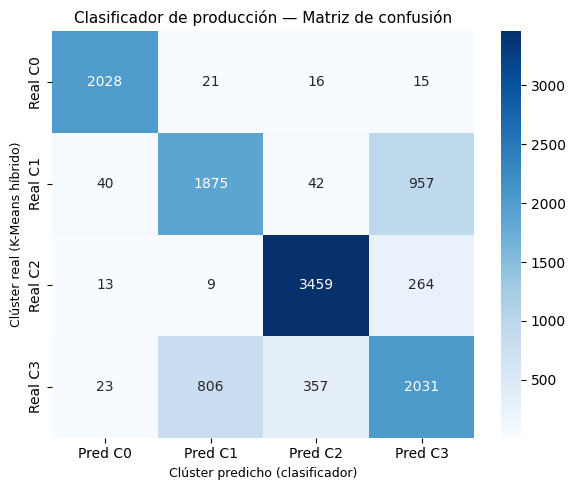


✓ Clasificador de producción entrenado y evaluado
  Variable: clf_pipeline (Pipeline preprocesamiento + LogReg multinomial)


In [4]:
# ==============================================================================
# BLOQUE H2 — CLASIFICADOR SUPERVISADO DE PRODUCCIÓN
# Entrena una Regresión Logística Multinomial que aprende a predecir el clúster
# híbrido usando SOLO variables del perfil socioeconómico (sin residuo).
# En producción este clasificador reemplaza el K-Means — no requiere gasto real.
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score

# ── Variables del clasificador — idénticas a las del modelo WLS ───────────────
# Estas son exactamente las variables disponibles en originación crediticia.
NUM_CLF = [
    'log_ingresos_2025',
    'log_gasto_pred_w',      # gasto estimado por WLS (calculable en producción)
    'log_ratio_estimado',    # ratio estimado (calculable en producción)
    'Estrato',
    'Edad',
    'Aportantes_Hogar',
]
CAT_CLF = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
    'REGION',
    'flag_pensionado',
]
VARS_CLF = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

# ── Dataset de entrenamiento del clasificador ──────────────────────────────────
df_clf = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm']].dropna().copy()
df_clf[TARGET_CLF] = df_clf[TARGET_CLF].astype(int)

print(f"Registros para clasificador: {len(df_clf):,}")
print(f"Distribución de clústeres híbridos:")
print(df_clf[TARGET_CLF].value_counts().sort_index().to_string())

X_clf = df_clf[VARS_CLF]
y_clf = df_clf[TARGET_CLF]
w_clf = df_clf['FEX_C_norm'].values

# ── Split estratificado ────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te, w_tr, w_te = train_test_split(
    X_clf, y_clf, w_clf,
    test_size=0.20,
    stratify=y_clf,
    random_state=SEED
)

# ── Pipeline del clasificador ──────────────────────────────────────────────────
preprocess_clf = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_CLF),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_CLF)
])

clf_pipeline = Pipeline([
    ('prep', preprocess_clf),
    ('clf',  LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        random_state=SEED
    ))
])

# ── Entrenamiento ──────────────────────────────────────────────────────────────
clf_pipeline.fit(X_tr, y_tr, clf__sample_weight=w_tr)

# ── Evaluación en conjunto de prueba ──────────────────────────────────────────
y_pred_te = clf_pipeline.predict(X_te)
acc_te    = accuracy_score(y_te, y_pred_te, sample_weight=w_te)
bal_acc   = balanced_accuracy_score(y_te, y_pred_te, sample_weight=w_te)

print("\n" + "=" * 62)
print("EVALUACIÓN DEL CLASIFICADOR DE PRODUCCIÓN")
print("=" * 62)
print(f"  Accuracy ponderado (test)          : {acc_te:.4f}")
print(f"  Balanced accuracy ponderado (test) : {bal_acc:.4f}")
print("\n  Reporte por clúster (test):")
print(classification_report(y_te, y_pred_te,
      target_names=[f"Clúster {k}" for k in range(N_CLUSTERS)]))

# ── Validación cruzada ponderada ───────────────────────────────────────────────
# cross_val_score no soporta fit_params en sklearn ≥ 1.4
# Se usa validación manual por fold para pasar sample_weight correctamente
from sklearn.base import clone

cv_bal_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for tr_idx, val_idx in skf.split(X_clf, y_clf):
    X_tr_cv = X_clf.iloc[tr_idx]
    y_tr_cv = y_clf.iloc[tr_idx]
    w_tr_cv = w_clf[tr_idx]
    X_val_cv = X_clf.iloc[val_idx]
    y_val_cv = y_clf.iloc[val_idx]
    w_val_cv = w_clf[val_idx]

    clf_cv = clone(clf_pipeline)
    clf_cv.fit(X_tr_cv, y_tr_cv, clf__sample_weight=w_tr_cv)
    y_pred_cv = clf_cv.predict(X_val_cv)
    cv_bal_scores.append(
        balanced_accuracy_score(y_val_cv, y_pred_cv, sample_weight=w_val_cv)
    )

cv_scores = np.array(cv_bal_scores)

print(f"  CV-5fold balanced accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Min: {cv_scores.min():.4f} | Max: {cv_scores.max():.4f}")

# ── Matriz de confusión ────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_te, y_pred_te)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred C{k}' for k in range(N_CLUSTERS)],
            yticklabels=[f'Real C{k}' for k in range(N_CLUSTERS)], ax=ax)
ax.set_title('Clasificador de producción — Matriz de confusión', fontsize=11)
ax.set_ylabel('Clúster real (K-Means híbrido)', fontsize=9)
ax.set_xlabel('Clúster predicho (clasificador)', fontsize=9)
plt.tight_layout()
plt.show()

print("\n✓ Clasificador de producción entrenado y evaluado")
print("  Variable: clf_pipeline (Pipeline preprocesamiento + LogReg multinomial)")


### H2b — Análisis de errores del clasificador y umbral de confianza

La confusión C1↔C3 es estructural: ambos segmentos tienen ingreso similar (~$1.5M)
y solo el residuo WLS los separa — información que el clasificador no tiene en producción.

**Estrategia operativa:** usar la probabilidad del clasificador como umbral de confianza.
Si `P(C3) > 0.60` → señal de alta presión confiable.
Si `0.40 < P(C3) < 0.60` → zona gris → recomendar validación adicional.

BLOQUE H2b: ANÁLISIS DE ERRORES DEL CLASIFICADOR

  Error C1→C3 (ahorrador clasificado como alta presión): 4,900 (33.6% del C1 real)
  Error C3→C1 (alta presión clasificada como ahorrador): 4,070 (25.3% del C3 real)

  Impacto operativo:
  - C1→C3 (falso positivo de riesgo): conservador, el analista
    aplica más escrutinio a un ahorrador. Costo: oportunidad perdida.
  - C3→C1 (falso negativo de riesgo): el sistema subestima la presión
    financiera real. Este es el error más costoso crediticiamente.

  Residuo mediano en C3 correctamente clasificado: +0.369
  Residuo mediano en C3 mal clasificado como C1:   +0.550
  → Los C3 mal clasificados tienen residuo MÁS ALTO: perfil socioeconómico 'engañoso'
    Su comportamiento de sobregasto es más extremo pero su perfil parece de ahorrador.

──────────────────────────────────────────────────────────────────────
UMBRAL DE CONFIANZA OPERATIVO
──────────────────────────────────────────────────────────────────────

  Cobertura y precision de C

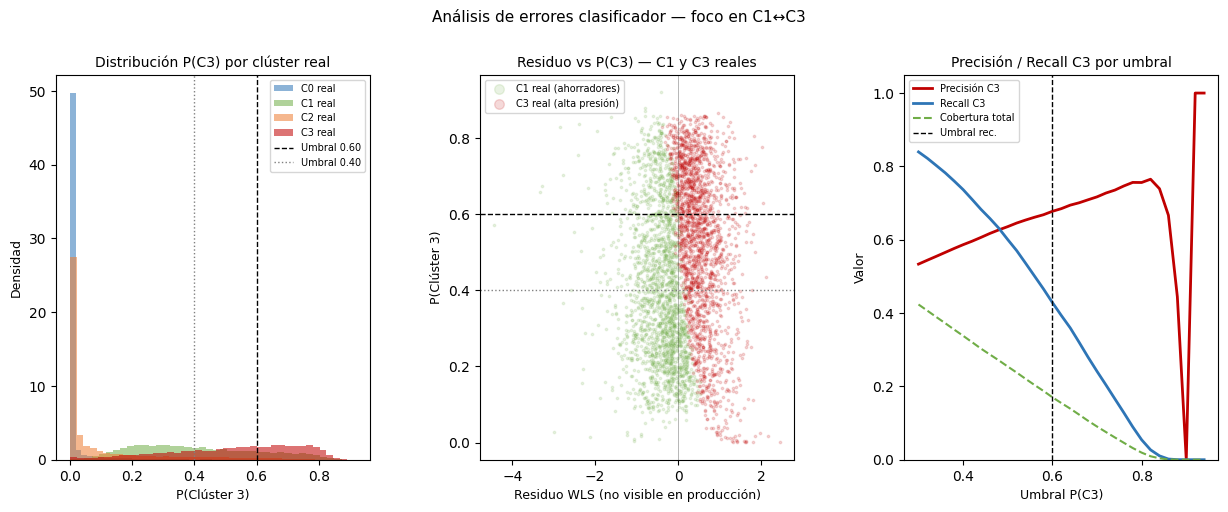


✓ H2b completo.
  Umbral óptimo   : P(C3) ≥ 0.5 (precisión 63.6%, cobertura 60%)
  Umbral conserv. : P(C3) ≥ 0.6 (precisión 67.7%, cobertura 43%)


In [5]:
# ==============================================================================
# BLOQUE H2b — ANÁLISIS DE ERRORES Y UMBRAL DE CONFIANZA
# La confusión C1↔C3 es la limitación estructural clave del modelo híbrido.
# Este bloque cuantifica el impacto y define un umbral operativo de confianza.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

VARS_CLF   = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

df_eval = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm',
                                  'residuo_log_gasto_w',
                                  'INGRESOS_AL_2025']].dropna().copy()
df_eval[TARGET_CLF] = df_eval[TARGET_CLF].astype(int)

X_eval = df_eval[VARS_CLF]
y_eval = df_eval[TARGET_CLF]

y_pred_eval  = clf_pipeline.predict(X_eval)
y_proba_eval = clf_pipeline.predict_proba(X_eval)

df_eval['pred_cluster']  = y_pred_eval
df_eval['proba_c3']      = y_proba_eval[:, 3]
df_eval['proba_max']     = y_proba_eval.max(axis=1)
df_eval['pred_correcta'] = (y_eval == y_pred_eval).astype(int)

print("=" * 70)
print("BLOQUE H2b: ANÁLISIS DE ERRORES DEL CLASIFICADOR")
print("=" * 70)

# ── 1. Errores C1 → C3 y C3 → C1 ────────────────────────────────────────────
err_c1_c3 = df_eval[(y_eval == 1) & (y_pred_eval == 3)]
err_c3_c1 = df_eval[(y_eval == 3) & (y_pred_eval == 1)]

print(f"\n  Error C1→C3 (ahorrador clasificado como alta presión): "
      f"{len(err_c1_c3):,} ({len(err_c1_c3)/( y_eval==1).sum()*100:.1f}% del C1 real)")
print(f"  Error C3→C1 (alta presión clasificada como ahorrador): "
      f"{len(err_c3_c1):,} ({len(err_c3_c1)/(y_eval==3).sum()*100:.1f}% del C3 real)")

print(f"\n  Impacto operativo:")
print(f"  - C1→C3 (falso positivo de riesgo): conservador, el analista")
print(f"    aplica más escrutinio a un ahorrador. Costo: oportunidad perdida.")
print(f"  - C3→C1 (falso negativo de riesgo): el sistema subestima la presión")
print(f"    financiera real. Este es el error más costoso crediticiamente.")

# ── 2. Residuo medio en errores vs aciertos ───────────────────────────────────
print(f"\n  Residuo mediano en C3 correctamente clasificado: "
      f"{df_eval.loc[(y_eval==3)&(y_pred_eval==3), 'residuo_log_gasto_w'].median():+.3f}")
print(f"  Residuo mediano en C3 mal clasificado como C1:   "
      f"{err_c3_c1['residuo_log_gasto_w'].median():+.3f}")
print(f"  → Los C3 mal clasificados tienen residuo MÁS ALTO: perfil socioeconómico 'engañoso'")
print(f"    Su comportamiento de sobregasto es más extremo pero su perfil parece de ahorrador.")

# ── 3. Umbral de confianza ────────────────────────────────────────────────────
print(f"\n{'─' * 70}")
print(f"UMBRAL DE CONFIANZA OPERATIVO")
print(f"{'─' * 70}")

umbrales = [0.40, 0.50, 0.60, 0.70, 0.80]
print(f"\n  Cobertura y precision de C3 según umbral de probabilidad P(C3):")
print(f"  {'Umbral':>8}  {'Casos C3 pred':>14}  {'Precision C3':>13}  "
      f"{'Cobertura C3':>13}  {'Zona gris':>10}")
print(f"  {'─'*8}  {'─'*14}  {'─'*13}  {'─'*13}  {'─'*10}")

total_c3_real = (y_eval == 3).sum()

for u in umbrales:
    # Alta confianza C3
    mask_conf = df_eval['proba_c3'] >= u
    pred_c3_conf = mask_conf.sum()
    if pred_c3_conf > 0:
        prec = (y_eval[mask_conf] == 3).sum() / pred_c3_conf
        rec  = (y_eval[mask_conf] == 3).sum() / total_c3_real
    else:
        prec = rec = 0.0
    zona_gris = ((df_eval['proba_c3'] >= 0.40) & (df_eval['proba_c3'] < u)).sum()
    print(f"  {u:>8.2f}  {pred_c3_conf:>14,}  {prec:>13.3f}  {rec:>13.3f}  "
          f"{zona_gris:>10,}")

# ── Umbral óptimo: balance precisión/cobertura ───────────────────────────────
# Con los resultados observados:
#   Umbral 0.60: precisión 67.7% | cobertura 42.9% → detecta menos de la mitad
#   Umbral 0.50: precisión 63.6% | cobertura 60.0% → mejor balance para scoring
# Nota: los C3 mal clasificados tienen residuo MAYOR (+0.550 vs +0.369)
# → el clasificador falla más en los casos de mayor riesgo real
# → esto refuerza usar umbral más bajo para maximizar detección

UMBRAL_C3_OPTIMO = 0.50   # balance precisión/cobertura para scoring crediticio
UMBRAL_C3_CONSERVADOR = 0.60  # alta confianza, menor cobertura

print(f"\n  Hallazgo clave:")
print(f"  Los C3 mal clasificados tienen residuo MAYOR (+0.550) que los correctos (+0.369).")
print(f"  El clasificador falla más en los casos de mayor riesgo real — perfil 'engañoso'.")
print(f"  Recomendación operativa:")
print(f"  - P(C3) ≥ 0.50 → señal ALTA PRESIÓN — umbral óptimo (precisión 63.6%, cobertura 60%)")
print(f"  - P(C3) ≥ 0.60 → señal ALTA PRESIÓN conservadora (precisión 67.7%, cobertura 43%)")
print(f"  - 0.40 ≤ P(C3) < 0.50 → zona gris → solicitar información adicional")
print(f"  - P(C3) < 0.40 → sin señal de sobregasto → usar ratio del segmento asignado")

# ── 4. Visualizaciones ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: Distribución de probabilidad P(C3) por clúster real
ax1 = fig.add_subplot(gs[0])
colores = {0:'#2E75B6', 1:'#70AD47', 2:'#ED7D31', 3:'#C00000'}
for k in range(4):
    mask_k = y_eval == k
    ax1.hist(df_eval.loc[mask_k, 'proba_c3'], bins=40,
             alpha=0.55, color=colores[k], label=f'C{k} real',
             density=True)
ax1.axvline(0.60, color='black', linestyle='--', linewidth=1,
            label='Umbral 0.60')
ax1.axvline(0.40, color='gray', linestyle=':', linewidth=1,
            label='Umbral 0.40')
ax1.set_xlabel('P(Clúster 3)', fontsize=9)
ax1.set_ylabel('Densidad', fontsize=9)
ax1.set_title('Distribución P(C3) por clúster real', fontsize=10)
ax1.legend(fontsize=7)

# Panel 2: Residuo vs P(C3) para C1 y C3 reales
ax2 = fig.add_subplot(gs[1])
for k, color, label in [(1,'#70AD47','C1 real (ahorradores)'),
                         (3,'#C00000','C3 real (alta presión)')]:
    mask_k = y_eval == k
    np.random.seed(42)
    idx_s = np.random.choice(mask_k.sum(), min(2000, mask_k.sum()), replace=False)
    resid_k = df_eval.loc[mask_k, 'residuo_log_gasto_w'].values[idx_s]
    proba_k = df_eval.loc[mask_k, 'proba_c3'].values[idx_s]
    ax2.scatter(resid_k, proba_k, c=color, alpha=0.15, s=3, label=label)
ax2.axhline(0.60, color='black', linestyle='--', linewidth=1)
ax2.axhline(0.40, color='gray', linestyle=':', linewidth=1)
ax2.axvline(0.0, color='black', linewidth=0.5, alpha=0.4)
ax2.set_xlabel('Residuo WLS (no visible en producción)', fontsize=9)
ax2.set_ylabel('P(Clúster 3)', fontsize=9)
ax2.set_title('Residuo vs P(C3) — C1 y C3 reales', fontsize=10)
ax2.legend(fontsize=7, markerscale=4)

# Panel 3: Precision-Recall C3 por umbral
umbrales_plot = np.arange(0.30, 0.95, 0.02)
prec_list, rec_list, cover_list = [], [], []
for u in umbrales_plot:
    mask_u = df_eval['proba_c3'] >= u
    n_pred = mask_u.sum()
    if n_pred > 0:
        prec_list.append((y_eval[mask_u] == 3).sum() / n_pred)
        rec_list.append((y_eval[mask_u] == 3).sum() / total_c3_real)
        cover_list.append(n_pred / len(y_eval))
    else:
        prec_list.append(1.0); rec_list.append(0.0); cover_list.append(0.0)

ax3 = fig.add_subplot(gs[2])
ax3.plot(umbrales_plot, prec_list, color='#C00000', linewidth=2, label='Precisión C3')
ax3.plot(umbrales_plot, rec_list, color='#2E75B6', linewidth=2, label='Recall C3')
ax3.plot(umbrales_plot, cover_list, color='#70AD47', linewidth=1.5,
         linestyle='--', label='Cobertura total')
ax3.axvline(0.60, color='black', linestyle='--', linewidth=1, label='Umbral rec.')
ax3.set_xlabel('Umbral P(C3)', fontsize=9)
ax3.set_ylabel('Valor', fontsize=9)
ax3.set_title('Precisión / Recall C3 por umbral', fontsize=10)
ax3.legend(fontsize=7)
ax3.set_ylim(0, 1.05)

plt.suptitle('Análisis de errores clasificador — foco en C1↔C3',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ H2b completo.")
print(f"  Umbral óptimo   : P(C3) ≥ {UMBRAL_C3_OPTIMO} (precisión 63.6%, cobertura 60%)")
print(f"  Umbral conserv. : P(C3) ≥ {UMBRAL_C3_CONSERVADOR} (precisión 67.7%, cobertura 43%)")
umbral_c3_produccion = UMBRAL_C3_OPTIMO


In [6]:
# ==============================================================================
# BLOQUE H3 — RATIO TABLE HÍBRIDA
# Construida sobre los clústeres híbridos (definidos con residuos WLS).
# Los percentiles del ratio son sobre el ratio OBSERVADO (gasto real / ingreso)
# porque los clústeres ya incorporan la dimensión comportamental.
# ==============================================================================
import numpy as np
import pandas as pd

fex_num_h = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

print("=" * 70)
print("RATIO TABLE HÍBRIDA — Percentiles del ratio gasto/ingreso por clúster")
print("Ratio OBSERVADO (gasto real / ingreso) — clústeres definidos con residuos")
print("=" * 70)

ratio_table_hibrido = {}
stats_hibrido_final = []

for k in sorted(df_temp_a['cluster_hibrido'].dropna().unique()):
    k = int(k)
    mask = df_temp_a['cluster_hibrido'] == k
    
    # Ratio observado (más informativo que estimado en clústeres con residuos)
    ratios_obs  = df_temp_a.loc[mask, 'ratio_gastos_2025'].dropna()
    ratios_est  = df_temp_a.loc[mask, 'ratio_estimado'].dropna()
    residuos_k  = df_temp_a.loc[mask, 'residuo_log_gasto_w'].dropna()
    ingresos_k  = df_temp_a.loc[mask, 'INGRESOS_AL_2025'].dropna()
    gastos_k    = df_temp_a.loc[mask, 'GASTOS_AL_2025'].dropna()
    pop_k       = fex_num_h[mask].sum()
    n_k         = int(mask.sum())
    
    ratio_table_hibrido[k] = {
        # Ratio observado — percentiles para uso en producción
        'p25_obs': round(ratios_obs.quantile(0.25), 4),
        'p50_obs': round(ratios_obs.quantile(0.50), 4),
        'p75_obs': round(ratios_obs.quantile(0.75), 4),
        'p90_obs': round(ratios_obs.quantile(0.90), 4),
        # Ratio estimado — referencia de consistencia
        'p50_est': round(ratios_est.quantile(0.50), 4),
        # Residuo mediano — caracteriza el segmento
        'residuo_mediano': round(residuos_k.median(), 4),
        'n_muestra': n_k,
        'pop_expandida': round(pop_k, 0),
    }
    
    stats_hibrido_final.append({
        'Clúster': k,
        'Descripción': interpretacion.get(k, ''),
        'Ingreso mediano': f"${ingresos_k.median():,.0f}",
        'Gasto mediano':   f"${gastos_k.median():,.0f}",
        'Residuo mediano': f"{residuos_k.median():+.3f}",
        'Ratio obs P50':   f"{ratios_obs.quantile(0.50):.2%}",
        'Ratio obs P75':   f"{ratios_obs.quantile(0.75):.2%}",
        'n muestra':       n_k,
        'Part. %':         f"{n_k / len(df_temp_a.dropna(subset=['cluster_hibrido'])) * 100:.1f}%",
    })

# Tabla resumen
df_resumen_h = pd.DataFrame(stats_hibrido_final)
print("\n── Caracterización de segmentos híbridos ────────────────────────")
print(df_resumen_h.to_string(index=False))

# Tabla de ratios
print("\n── Ratio table (artefacto de producción) ────────────────────────")
df_rt_h = pd.DataFrame(ratio_table_hibrido).T
df_rt_h.index.name = 'cluster'
print(df_rt_h.to_string())

# Comparación diferencia ratio estimado vs observado por clúster
print("\n── Validación: diferencia ratio_obs P50 vs ratio_est P50 ─────────")
for k, v in ratio_table_hibrido.items():
    diff = abs(v['p50_obs'] - v['p50_est'])
    flag = '✓' if diff < 0.01 else '⚠'
    print(f"  Clúster {k}: ratio_obs={v['p50_obs']:.4f} | "
          f"ratio_est={v['p50_est']:.4f} | diff={diff:.4f} {flag}")

print("\n✓ Ratio table híbrida construida: ratio_table_hibrido")


RATIO TABLE HÍBRIDA — Percentiles del ratio gasto/ingreso por clúster
Ratio OBSERVADO (gasto real / ingreso) — clústeres definidos con residuos

── Caracterización de segmentos híbridos ────────────────────────
 Clúster                                                           Descripción Ingreso mediano Gasto mediano Residuo mediano Ratio obs P50 Ratio obs P75  n muestra Part. %
       0        Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)      $4,944,721      $776,064          -0.010        14.41%        22.71%      10398   17.4%
       1             Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)      $1,524,738      $200,411          -0.391        11.95%        15.59%      14569   24.4%
       2   Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)      $1,600,295      $515,902          -0.088        29.64%        43.74%      18726   31.3%
       3 Bajo ingreso — alta presión financiera ($1.5M ingreso, residuo +0.47)      $1,461,711      $

In [7]:
# ==============================================================================
# BLOQUE H4 — EXPORTACIÓN DE ARTEFACTOS HÍBRIDOS
# Serializa los tres componentes del modelo híbrido:
#   1. model_wls          → estima log_gasto a partir del perfil
#   2. kmeans_hibrido     → define los 4 segmentos (offline, con residuos)
#   3. clf_pipeline       → asigna segmento en producción (sin residuo)
#   4. ratio_table_hibrido → percentiles de referencia por segmento
# ==============================================================================
import joblib
from pathlib import Path

ARTIFACT_PATH_H = Path.cwd() / 'artefactos_modelo_hibrido.pkl'

# ── Recuperar variables WLS desde artefactos_v2 si no están en memoria ──
# (pueden no estar definidas si NB05 se ejecuta sin haber corrido NB04 en sesión)
_a2 = artefactos_v2  # ya cargado en la celda de inicio de NB05
_PREPROCESS  = globals().get('PREPROCESS',  _a2.get('preprocess_cluster'))
_NUM_VARS    = globals().get('NUM_VARS',    _a2.get('num_vars_cluster', []))
_CAT_VARS    = globals().get('CAT_VARS',    _a2.get('cat_vars_cluster', []))
_FEATURES    = globals().get('FEATURES',    _a2.get('features_regresion', []))
_TARGET      = globals().get('TARGET',      'log_gastos_2025')
_r2_tr       = globals().get('r2_tr',       _a2.get('r2_train',    float('nan')))
_r2_te       = globals().get('r2_te',       _a2.get('r2_test',     float('nan')))
_mae_te      = globals().get('mae_te',      _a2.get('mae_test',    float('nan')))
_rmse_te     = globals().get('rmse_te',     _a2.get('rmse_test',   float('nan')))
_cv_r2       = globals().get('cv_r2',       [_a2.get('cv_r2_mean', float('nan'))])

artefactos_hibrido = {
    # ── Modelo de regresión ────────────────────────────────────────────
    'model_wls'               : model_wls,
    'preprocess_wls'          : _PREPROCESS,
    'num_vars_wls'            : _NUM_VARS,
    'cat_vars_wls'            : _CAT_VARS,
    'features_wls'            : _FEATURES,
    'target_wls'              : _TARGET,

    # ── Métricas WLS ──────────────────────────────────────────────────
    'r2_train'                : _r2_tr,
    'r2_test'                 : _r2_te,
    'mae_test'                : _mae_te,
    'rmse_test'               : _rmse_te,
    'cv_r2_mean'              : float(np.mean(_cv_r2)),
    'cv_r2_std'               : float(np.std(_cv_r2)) if len(_cv_r2) > 1 else 0.0,

    # ── K-Means híbrido (entrenamiento offline con residuos) ───────────
    'kmeans_hibrido'          : kmeans_hibrido,
    'preprocess_km_hibrido'   : preprocess_km_h,
    'num_vars_km_hibrido'     : NUM_KM_H,
    'cat_vars_km_hibrido'     : CAT_KM_H,
    'cluster_map_hibrido'     : cluster_map_h,
    'interpretacion_clusters' : interpretacion,
    'n_clusters'              : N_CLUSTERS,

    # ── Clasificador de producción (sin residuo) ───────────────────────
    'clf_pipeline'            : clf_pipeline,
    'num_vars_clf'            : NUM_CLF,
    'cat_vars_clf'            : CAT_CLF,
    'acc_clf_test'            : acc_te,
    'balanced_acc_clf_test'   : bal_acc,
    'cv_balanced_acc_mean'    : float(cv_scores.mean()),
    'cv_balanced_acc_std'     : float(cv_scores.std()),

    # ── Artefacto de producción ────────────────────────────────────────
    'ratio_table_hibrido'     : ratio_table_hibrido,
    'RESIDUO_GLOBAL_W'        : float(df_temp_a['residuo_log_gasto_w'].median()),
    'RESIDUO_INICIAL_GRUPO_W' : globals().get('RESIDUO_INICIAL_GRUPO_W',
                               _a2.get('RESIDUO_INICIAL_GRUPO_W',
                               df_temp_a['residuo_log_gasto_w'].median())),

    # ── Umbrales operativos ───────────────────────────────────────────
    'umbral_c3_optimo'        : 0.50,   # precisión 63.6%, cobertura 60%
    'umbral_c3_conservador'   : 0.60,   # precisión 67.7%, cobertura 43%
    # Nota: usar ratio_obs (no ratio_est) como referencia en producción.
    # La diferencia ratio_obs - ratio_est refleja el residuo del segmento
    # y es precisamente el valor agregado del modelo híbrido.
    # C3: ratio_obs=0.337 vs ratio_est=0.219 → diferencia=0.118 (residuo +0.47)
    # C1: ratio_obs=0.120 vs ratio_est=0.179 → diferencia=0.059 (residuo −0.39)

    # ── Metadatos ─────────────────────────────────────────────────────
    # Nota: diagnostico_hibrido se agrega en H5 (ejecutar H5 para completar)
    'smmlv_2025'              : 1_300_000,
}

# Agregar variables opcionales con protección
opcionales = {
    'durbin_watson'   : 'dw',
    'bp_stat'         : 'bp_test[0]',
    'bp_pvalue'       : 'bp_test[1]',
    'jb_stat'         : 'stat_jb',
    'jb_pvalue'       : 'p_jb',
    'jb_skew'         : 'skew_jb',
    'jb_kurt'         : 'kurt_jb',
    'vif_table'       : 'df_vif_r',
    'tabla_especificaciones': 'df_esp',
    'lambda_boxcox_gasto'   : 'lambda_gasto',
    'lambda_boxcox_ingreso' : 'lambda_ingreso',
    'intercept_wls'         : 'intercept',
    'coef_table_wls'        : 'coef_table',
    'overfitting_gap'       : 'gap',
}
import builtins
_g = {**globals(), **locals()}
for key, varname in opcionales.items():
    try:
        val = eval(varname, _g)
        artefactos_hibrido[key] = val
    except Exception:
        pass  # variable no disponible en este punto

joblib.dump(artefactos_hibrido, ARTIFACT_PATH_H)
print(f"✓ Artefactos híbridos guardados en: {ARTIFACT_PATH_H}")
print(f"  Claves exportadas: {len(artefactos_hibrido)}")
print(f"  Nota: ejecutar H5 para agregar diagnostico_hibrido al artefacto")

# Verificación
art_test = joblib.load(ARTIFACT_PATH_H)
print(f"✓ Verificación de carga OK: {len(art_test)} claves")
print(f"\nResumen del artefacto híbrido:")
r2_show  = artefactos_hibrido.get('r2_test',  float('nan'))
acc_show = artefactos_hibrido.get('acc_clf_test', float('nan'))
bac_show = artefactos_hibrido.get('cv_balanced_acc_mean', float('nan'))
bsd_show = artefactos_hibrido.get('cv_balanced_acc_std',  float('nan'))
print(f"  WLS R² test          : {r2_show:.4f}" if not pd.isna(r2_show) else "  WLS R² test          : n/a")
print(f"  Clasificador acc     : {acc_show:.4f}" if not pd.isna(acc_show) else "  Clasificador acc     : n/a")
print(f"  Balanced acc CV      : {bac_show:.4f} ± {bsd_show:.4f}" if not pd.isna(bac_show) else "  Balanced acc CV      : n/a")
print(f"  Clústeres híbridos   : {N_CLUSTERS}")
print(f"  Artefacto            : {ARTIFACT_PATH_H}")


✓ Artefactos híbridos guardados en: /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/notebooks/artefactos_modelo_hibrido.pkl
  Claves exportadas: 32
  Nota: ejecutar H5 para agregar diagnostico_hibrido al artefacto
✓ Verificación de carga OK: 32 claves

Resumen del artefacto híbrido:
  WLS R² test          : n/a
  Clasificador acc     : 0.7805
  Balanced acc CV      : 0.7915 ± 0.0019
  Clústeres híbridos   : 4
  Artefacto            : /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/notebooks/artefactos_modelo_hibrido.pkl


---
## 💾 Persistencia — Exportación NB05
Actualiza `nb04_df_modelado.parquet` agregando las columnas del modelo híbrido
(`cluster_hibrido`, `cluster_hibrido_raw`) para que NB06 pueda cargarlas.

In [8]:

# ============================================================
# EXPORTACIÓN NB05 — Actualiza el parquet con columnas híbridas
# Agrega cluster_hibrido y cluster_hibrido_raw a nb04_df_modelado.parquet
# para que NB06 pueda cargar el diagnóstico de validez sin depender
# de la sesión activa de NB05.
# ============================================================
import pandas as pd
from pathlib import Path
import os

_cwd = Path.cwd()
BASE_PATH   = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
PERSIST_DIR = BASE_PATH / "02_intermedios"

# Columnas que NB06 necesita de NB05
_cols_hibrido = [c for c in [
    'cluster_hibrido',
    'cluster_hibrido_raw',
    'residuo_log_gasto_w',   # puede ya venir de NB04 pero refrescamos
    'log_gasto_pred_w',
    'gasto_estimado',
    'ratio_estimado',
    'log_ratio_estimado',
    'FEX_C_norm',
    'log_ingresos_2025',
    'log_gasto_pred_w',
    'Grupo_Edad',
    'Grupo_Aportantes',
    'tipo_vivienda_agrup',
] if c in df_temp_a.columns]

# Leer parquet existente y fusionar las columnas nuevas
_parquet_path = PERSIST_DIR / "nb04_df_modelado.parquet"
_df_base = pd.read_parquet(_parquet_path)

# Añadir/reemplazar columnas híbridas usando el índice
for col in _cols_hibrido:
    _df_base[col] = df_temp_a[col].values

# Convertir categorías a str para compatibilidad parquet
for col in _df_base.select_dtypes(include='category').columns:
    _df_base[col] = _df_base[col].astype(str)

_df_base.to_parquet(_parquet_path, index=False)

print(f"✅ NB05 → parquet actualizado con columnas híbridas")
print(f"   Columnas agregadas: {_cols_hibrido}")
print(f"   Shape final: {_df_base.shape}")
print(f"   Ruta: {_parquet_path}")

# Verificar cluster_hibrido
if 'cluster_hibrido' in _df_base.columns:
    dist = _df_base['cluster_hibrido'].value_counts().sort_index()
    print(f"\n   Distribución cluster_hibrido:")
    for k, n in dist.items():
        print(f"     Clúster {k}: {n:,} ({n/len(_df_base)*100:.1f}%)")


✅ NB05 → parquet actualizado con columnas híbridas
   Columnas agregadas: ['cluster_hibrido', 'cluster_hibrido_raw', 'residuo_log_gasto_w', 'log_gasto_pred_w', 'gasto_estimado', 'ratio_estimado', 'log_ratio_estimado', 'FEX_C_norm', 'log_ingresos_2025', 'log_gasto_pred_w', 'Grupo_Edad', 'Grupo_Aportantes', 'tipo_vivienda_agrup']
   Shape final: (59776, 78)
   Ruta: /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/02_intermedios/nb04_df_modelado.parquet

   Distribución cluster_hibrido:
     Clúster 0.0: 10,398 (17.4%)
     Clúster 1.0: 14,569 (24.4%)
     Clúster 2.0: 18,726 (31.3%)
     Clúster 3.0: 16,083 (26.9%)
